## 1. Import Libraries


In [51]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

## 2. Load Real Dataset (Titanic)


In [33]:
df=sns.load_dataset('titanic')

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [35]:
df[['age', 'fare']].isnull().sum()

,0
age,177
fare,0


In [36]:
# Select numerical columns for transformation
df=df[['age','fare']].dropna()

## 3. Check Distribution (Before Transformation)


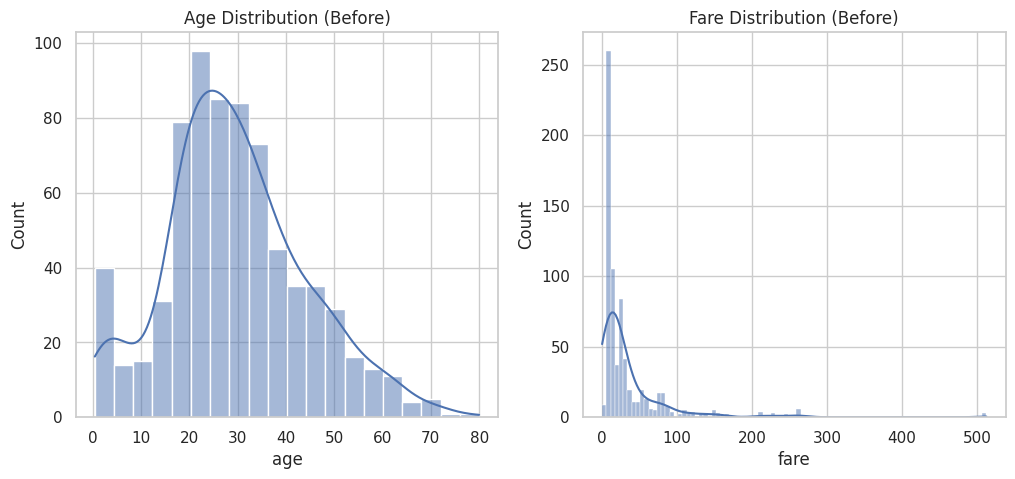

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution (Before)")

plt.subplot(1,2,2)
sns.histplot(df['fare'], kde=True)
plt.title("Fare Distribution (Before)")

plt.show()

## 4. Check Skewness


In [38]:
print("Skewness BEFORE:")
print(df.skew())

Skewness BEFORE:
age     0.389108
fare    4.653630
dtype: float64


## 5. Train-Test Split (IMPORTANT RULE)


In [39]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)


## 6. FUNCTION TRANSFORMATIONS


### 6.1. Log Transform (use log1p to handle zero safely)


In [40]:
log_transformer=FunctionTransformer(np.log1p)
X_train_log=log_transformer.fit_transform(X_train)
X_test_log=log_transformer.fit_transform(X_test)

### 6.2 Square Root Transform


In [41]:
sqrt_transformer=FunctionTransformer(np.sqrt)
X_train_sqrt=sqrt_transformer.fit_transform(X_train)
X_test_sqrt=sqrt_transformer.fit_transform(X_test)

### 6.3 Reciprocal Transform


In [42]:
reciprocal_transformer=FunctionTransformer(lambda x:1/(x+1))

X_train_recip=reciprocal_transformer.fit_transform(X_train)
X_test_recip=reciprocal_transformer.fit_transform(X_test)

## 7. POWER TRANSFORMATIONS


### 7.1 Box-Cox (ONLY positive values)


In [43]:
boxcox=PowerTransformer(method='box-cox')
X_train_boxcox=boxcox.fit_transform(X_train+1)
X_test_boxcox=boxcox.fit_transform(X_test+1)

### 7.2 Yeo-Johnson (handles negative values)


In [44]:
yeo = PowerTransformer(method='yeo-johnson')

X_train_yeo = yeo.fit_transform(X_train)
X_test_yeo = yeo.transform(X_test)

## 8. Compare Distributions (Before vs After)


In [45]:
plt.figure(figsize=(12,5))

def plot_comparison(original, transformed, title):
  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  sns.histplot(original, kde=True)
  plt.title("Original")

  plt.subplot(1,2,2) # Changed to 1,2,2 to plot side-by-side
  sns.histplot(transformed, kde=True)
  plt.title(title)

<Figure size 1200x500 with 0 Axes>

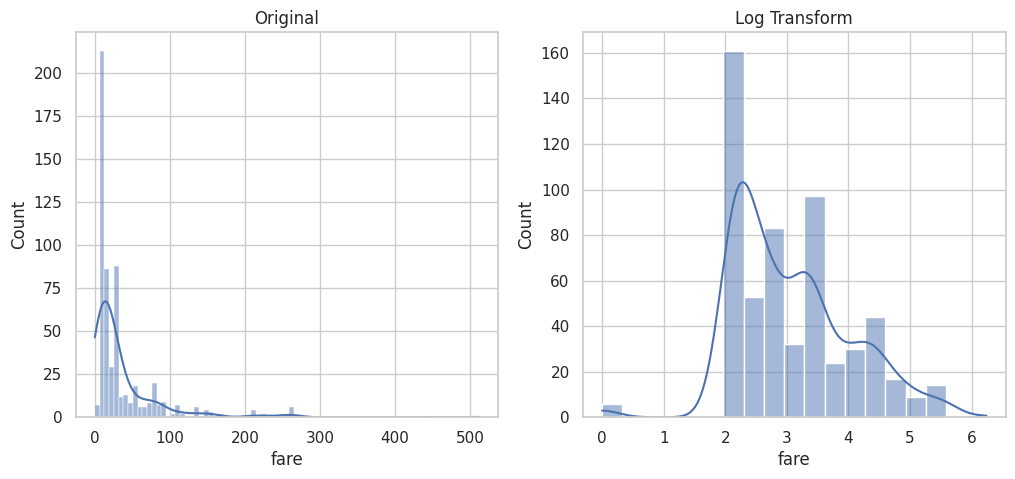

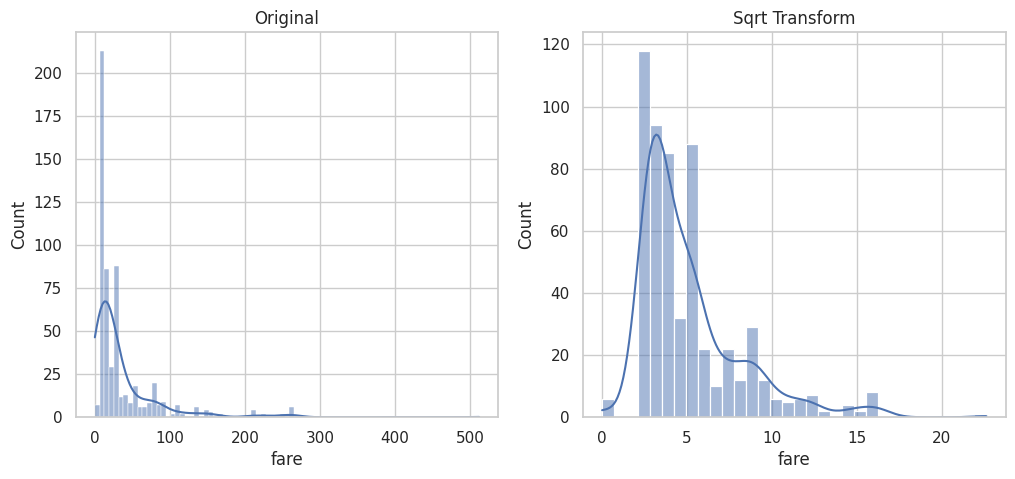

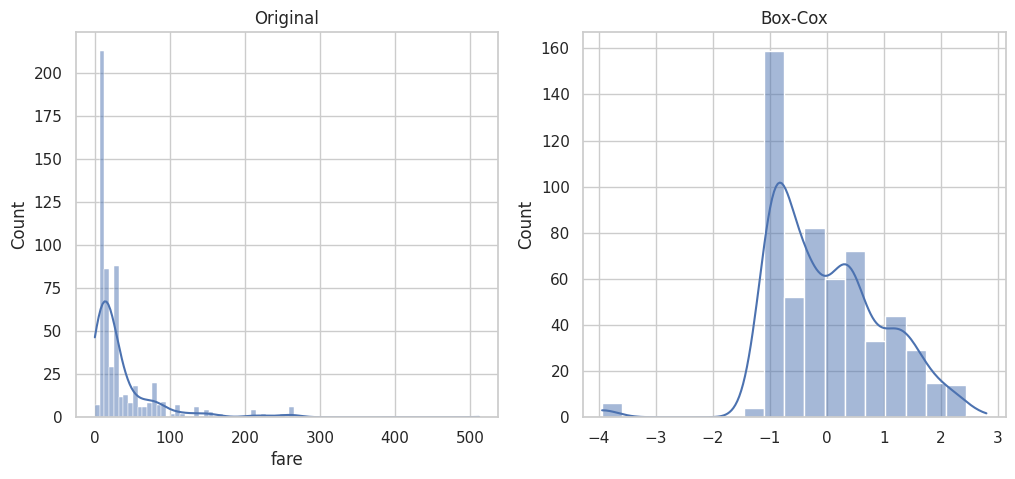

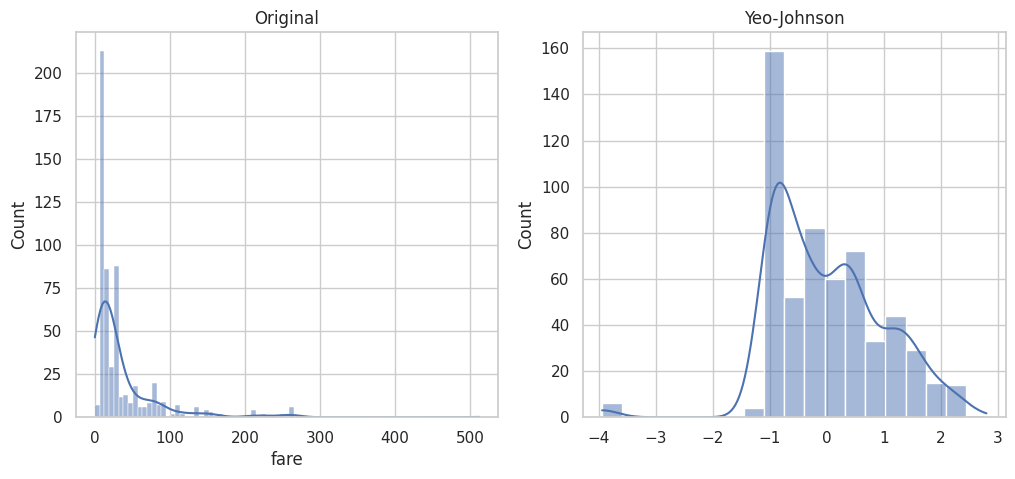

In [46]:
plot_comparison(X_train['fare'], X_train_log['fare'], 'Log Transform')
plot_comparison(X_train['fare'], X_train_sqrt['fare'], 'Sqrt Transform')
plot_comparison(X_train['fare'], X_train_boxcox[:,1], 'Box-Cox')
plot_comparison(X_train['fare'], X_train_yeo[:,1], 'Yeo-Johnson')

## 9. Skewness After Transformation


In [50]:
print("Skewness After Log")
print(pd.DataFrame(X_train_log, columns=X_train.columns).skew())
print()
print("Skewness After Box-Cox")
print(pd.DataFrame(X_train_boxcox, columns=X_train.columns).skew())
print()
print("Skewness After Yeo-Johnson")
print(pd.DataFrame(X_train_yeo, columns=X_train.columns).skew())


Skewness After Log
age    -1.935597
fare    0.477046
dtype: float64

Skewness After Box-Cox
age    -0.026866
fare   -0.041658
dtype: float64

Skewness After Yeo-Johnson
age    -0.026866
fare   -0.041658
dtype: float64


## 10. QQ Plot


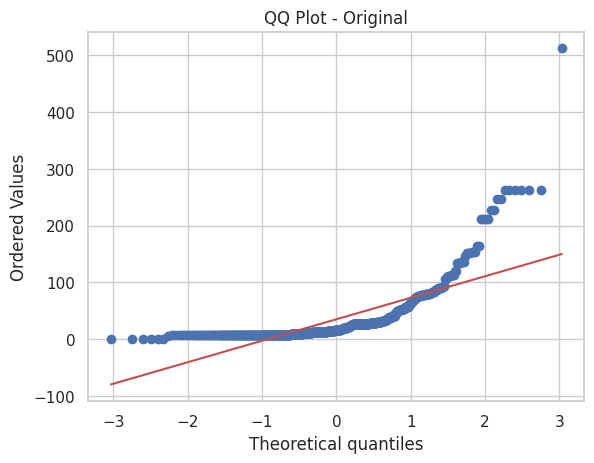

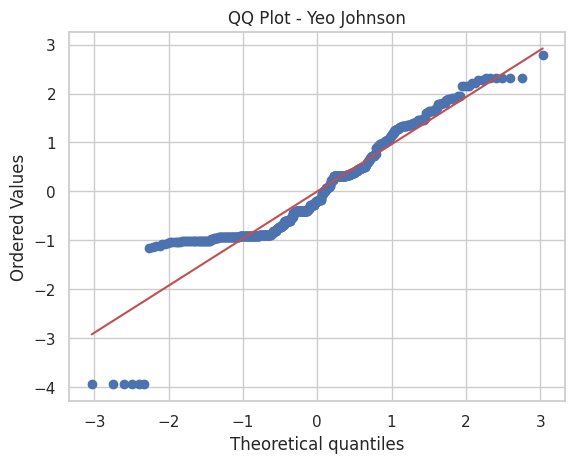

In [52]:
def qq_plot(data, title):
  stats.probplot(data, dist='norm', plot=plt)
  plt.title(title)
  plt.show()

qq_plot(X_train['fare'], "QQ Plot - Original")
qq_plot(X_train_yeo[:,1], "QQ Plot - Yeo Johnson")